
#  Regression — California Housing 



##  데이터 준비 



In [3]:
#  데이터 준비
# 필요한 라이브러리 import
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 로드
housing = fetch_california_housing()
df = pd.DataFrame(housing.data , columns = housing.feature_names)
df['MedHouseVal'] = housing.target

# shape , describe(), 결측치 여부 출력하기
print(f'데이터의 shape : {df.shape}')

print(f'\n데이터 describe : {df.describe().round(3)}')

print(f'\n데이터의 각 변수 당 결측치 개수 : {df.isnull().sum()}')
print(f'\n데이터의 총 결측치 개수 = {df.isnull().sum().sum()}')
print('데이터의 총 결측치 개수가 0개이므로 이 데이터는 결측치가 없다.')

# train : test = 8 : 2 로 분리하기
x = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

x_train , x_test , y_train , y_test = train_test_split(x, y, test_size=0.2, random_state = 42)
print(f'\nx_train 데이터 shape : {x_train.shape} / x_test 데이터 shape : {x_test.shape}')

# StandardScaler 적용하기
scaler = StandardScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns = x.columns)
x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns = x.columns)
print('train데이터를 바탕으로 정규화를 진행하고 그거와 동일하게 test데이터에 적용하기 때문에 ' \
'train 데이터에는 fit_transform을 하고 test 데이터에는 transform 만 하는 것.(fit은 train데이터에만 해야함)')

print(f'train 평균값 = {x.columns[0]} : {x_train_scaled.iloc[:,0].mean():.3f}')
print(f'train 표준편차 = {x.columns[0]} : {x_train_scaled.iloc[:,0].std():.3f}')

print(f'\ntest 평균값 = {x.columns[0]} : {x_test_scaled.iloc[:,0].mean():.3f}')
print(f'test 표준편차 = {x.columns[0]} : {x_test_scaled.iloc[:,0].std():.3f}')
print('train 데이터에 fit 한 것을 test 데이터에 적용한 것이기 때문에 train 데이터의 평균, 표준편차는 각각 1, 0 이지만 ' \
'test 데이터 변수의 평균과 표준편차는 0과 1이 아닐 수 있음')

데이터의 shape : (20640, 9)

데이터 describe :           MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.097    1425.477      3.071   
std        1.900     12.586      2.474      0.474    1132.462     10.386   
min        0.500      1.000      0.846      0.333       3.000      0.692   
25%        2.563     18.000      4.441      1.006     787.000      2.430   
50%        3.535     29.000      5.229      1.049    1166.000      2.818   
75%        4.743     37.000      6.052      1.100    1725.000      3.282   
max       15.000     52.000    141.909     34.067   35682.000   1243.333   

        Latitude  Longitude  MedHouseVal  
count  20640.000  20640.000    20640.000  
mean      35.632   -119.570        2.069  
std        2.136      2.004        1.154  
min       32.540   -124.350        0.150  
25%       33.930   -121.800        1.196  
50%       34.260 

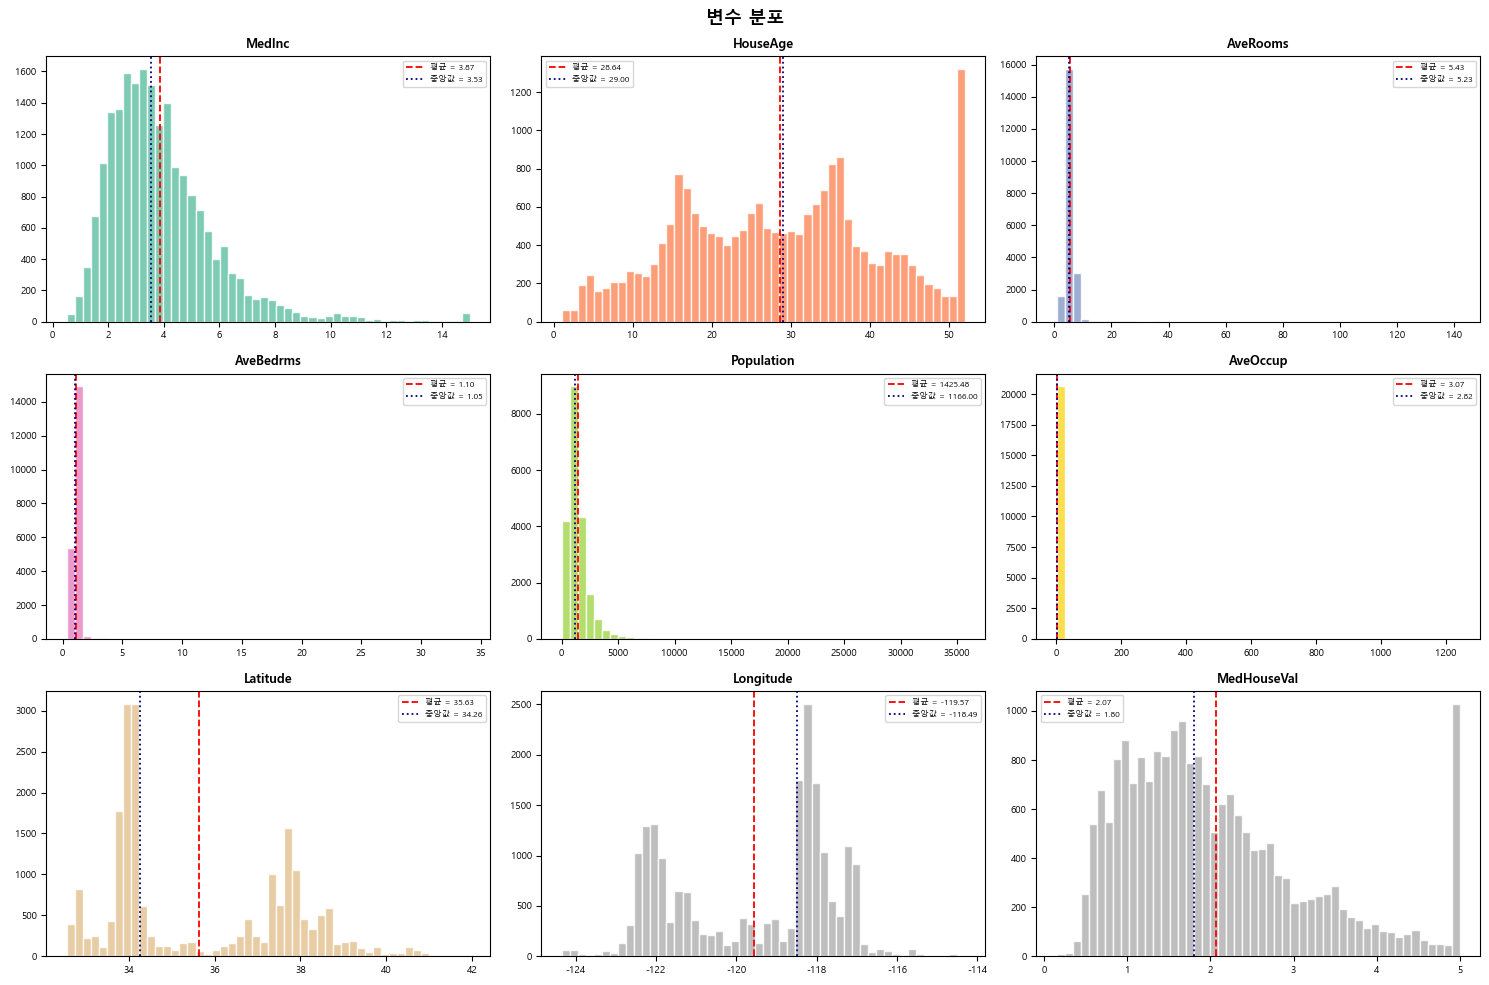

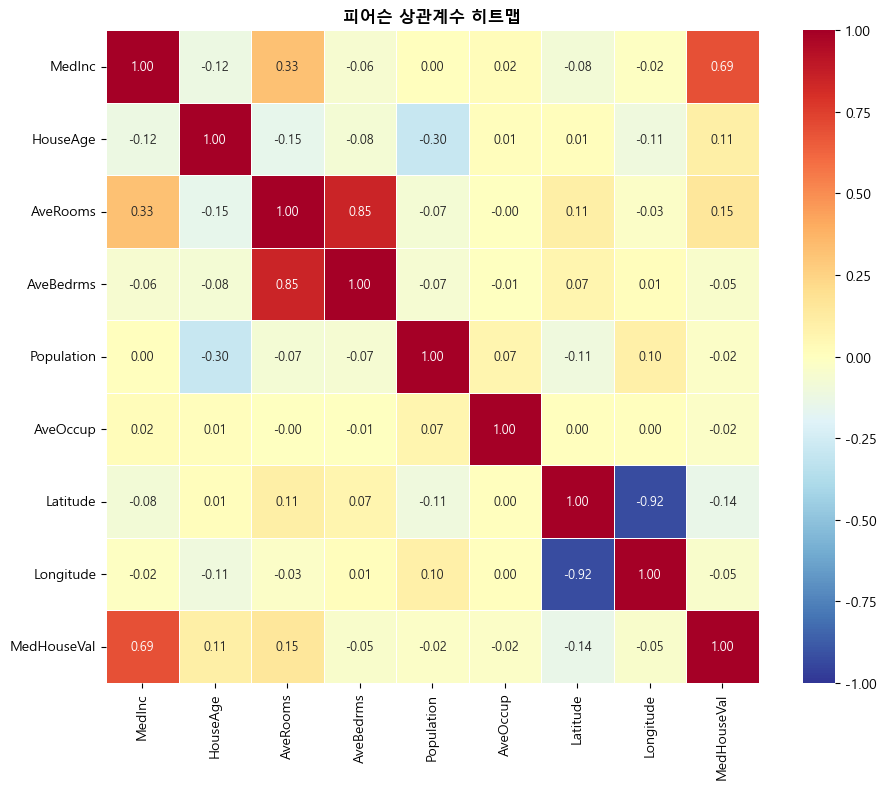

In [4]:

import seaborn as sns
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# feature 분포 히스토그램
fig, axes = plt.subplots(3, 3, figsize = (15,10))
fig.suptitle('변수 분포', fontsize = 13, fontweight = 'bold')
palette = plt.cm.Set2(np.linspace(0, 1, 9))
all_cols = list(x.columns) + ['MedHouseVal']

for i, (col,ax) in enumerate(zip(all_cols, axes.flatten())) :
    ax.hist(df[col], bins = 50, color=palette[i], edgecolor = 'white', alpha=0.85)
    ax.axvline(df[col].mean(), color = 'red', linestyle = '--', linewidth = 1.3, label = f'평균 = {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color = 'navy', linestyle = ':', linewidth = 1.3, label = f'중앙값 = {df[col].median():.2f}')
    ax.set_title(col, fontsize = 9, fontweight = 'bold')
    ax.legend(fontsize = 6) ; ax.tick_params(labelsize = 7)

plt.tight_layout()
plt.show()


# 상관관계 히트맵
fig, ax = plt.subplots(figsize = (10, 8))
sns.heatmap(df.corr(), annot = True , fmt = '.2f', cmap = 'RdYlBu_r',
            center = 0, vmin = -1, vmax = 1, linewidths = 0.5, linecolor = 'white',
            annot_kws = {'size':9}, square = True, ax=ax)
ax.set_title('피어슨 상관계수 히트맵', fontsize = 12, fontweight = 'bold')
plt.tight_layout()
plt.show()


 < 히스토그램 > 
> 각 변수의 히스토그램을 분석한 결과, MedInc, HouseAge, Latitude, Longitude 변수들은 데이터가 전 범위에 걸쳐 비교적 넓고 고르게 분포되어 있어 종속변수인 MedHouseVal을 설명하는 데 직접적인 기여를 할 것으로 판단된다. 특히 MedInc는 오른쪽으로 꼬리가 긴 양의 왜도를 보이며 대다수 지역의 소득은 낮고 일부 고소득 지역이 분포하는 특성을 보이며, HouseAge는 다양한 연령대의 주택이 고르게 존재함을 나타낸다. Latitude와 Longitude는 캘리포니아 지형 특성에 따라 특정 구간(위도 34~38, 경도 -122~-117)에 데이터가 집중되어 있으나, 전반적으로 값이 겹치지 않고 넓게 퍼져 있어 지리적 위치에 따른 가격 차이를 잘 반영할 것으로 보인다.
반면, AveRooms, AveBedrms, Population, AveOccup 변수들은 매우 소수의 구간에 데이터가 과도하게 밀집된 극단적인 양의 왜도를 보인다. 이는 일부 초고밀도 주거지나 특이 사례들이 매우 큰 값을 가지기 때문인 것 같다. 마지막으로 종속변수인 MedHouseVal은 5.0 부근에서 데이터가 급증하는 잘림현상이 관찰되는데, 이는 50만 달러 초과 주택이 모두 5.0으로 기록된 데이터 특성에 기인한다. 이러한 천장 효과는 고가 주택 예측의 정확도를 제한하는 요인이 될 수 있다.

< 상관계수 히트맵>
> 상관계수 히트맵에서 종속변수인 MedHouseVal와 설명변수 8개 관계를 먼저 보면, 
상관계수가 0.5 이상 -0.5이하인 변수가 MedInc가 유일하므로 가장 상관도가 높은 것은 MedInc라고 생각한다.
그리고 설명변수들 간의 상관계수를 보면 AveRooms & Avebedrms 상관계수가 0.85로 상당히 높다. 따라서 이 두 변수로 인한 다중공선성이 존재할 수 있으니 조심해야한다.
또한 Latitude & Longitude 상관계수가 -0.92로 매우 상관관계가 강하다. 따라서 이 두 변수로 인한 다중공선성도 주의해야할 것 같다.

## Feature Selection 


In [5]:
# Feature Selection
# 상관계수 계산 -> 상위 4개 feature 선택

corr_with_target = df.corr()['MedHouseVal'].drop('MedHouseVal')  # 설명변수들과 종속변수 간의 상관계수 계산
corr_abs_sorted = corr_with_target.abs().sort_values(ascending = False)   # 위에서 구한 상관계수를 절댓값 기준으로 내림차순 정렬 

print(f'MedHouseVal 변수와의 피어슨 상관계수 (절댓값 기준 내림차순) : ')
for name in corr_abs_sorted.index :  
    cor = corr_with_target[name]  # 절댓값 전의 상관계수 (+/-)
    print(f'{name:12s} : 상관계수 = {cor:+.4f} --> |상관계수| = {abs(cor):.4f}')

top4_features = corr_abs_sorted.index[:4].tolist()
print(f'\n선택된 상위 4개 변수 : {top4_features}')

# 선택된 feature만으로 새로운 train / test set 구성하기
x_train_4 = x_train_scaled[top4_features].reset_index(drop=True)  
x_test_4  = x_test_scaled[top4_features].reset_index(drop=True) 
y_train_4   = y_train.reset_index(drop=True) 
y_test_4    = y_test.reset_index(drop=True)  

print(f'''\n새로운 데이터 shape   
x_train_4: {x_train_4.shape}  
x_test_4: {x_test_4.shape}
''')



MedHouseVal 변수와의 피어슨 상관계수 (절댓값 기준 내림차순) : 
MedInc       : 상관계수 = +0.6881 --> |상관계수| = 0.6881
AveRooms     : 상관계수 = +0.1519 --> |상관계수| = 0.1519
Latitude     : 상관계수 = -0.1442 --> |상관계수| = 0.1442
HouseAge     : 상관계수 = +0.1056 --> |상관계수| = 0.1056
AveBedrms    : 상관계수 = -0.0467 --> |상관계수| = 0.0467
Longitude    : 상관계수 = -0.0460 --> |상관계수| = 0.0460
Population   : 상관계수 = -0.0246 --> |상관계수| = 0.0246
AveOccup     : 상관계수 = -0.0237 --> |상관계수| = 0.0237

선택된 상위 4개 변수 : ['MedInc', 'AveRooms', 'Latitude', 'HouseAge']

새로운 데이터 shape   
x_train_4: (16512, 4)  
x_test_4: (4128, 4)



(2) Feature Selection 해석

> 선택된 4개 feature : MedInc, AveRooms, Latitude, HouseAge

> 선택된 feature와 집값의 관계 :
1) MedInc : 이전에 상관계수를 통해서도 집값과 가장 상관도가 높은 변수로 예측했었다. 이 변수는 해당 블록 가구들의 중위 소득을 알려주는 변수이다. 따라서 높은 양의 상관관계를 보인다는 것은, 소득이 높으면 집값이 비싸다 즉 부자들이 모인 동네는 집값이 높게 형성되어있다는 것을 의미한다.
2) AveRooms : 이 변수는 방의 개수를 알려준다. 종속변수와 양의 상관관계로 방이 많을수록 집값이 비싸다는 것을 의미한다.
3) Latitude : 이 변수는 위도를 나타낸다. 즉 집이 얼마나 북쪽에 위치하는지를 알려주는데 음의 상관계수인 것을 통해 집이 북쪽에서 멀수록 집값이 비싸다는 것을 알 수 있다.
4) HouseAge : 이 변수는 집의 나이이다. 종속변수와의 상관계수가 양수인 것을 보아 지은지 오래된 집일수록 집값이 비싸다는 것을 알 수 있다.

> 상관계수가 높다고 해서 반드시 좋은 feature라고 할 수 없는 경우 :
상관계수가 높지만 좋은 feature가 아닌 예로는 다중공선성이 있다. 다중공선성은 설명변수들끼리의 관계가 높을 때 나타나는데 예를 들어 A변수와 B변수가 종속변수인 C변수와 각각 상관계수가 높지만 A변수와 B변수 사이의 상관계수도 높은 경우에 예측모델에 A, B 변수 2개를 모두 사용하면 동일한 정보를 2번 넣게되는 것이다. 그러면 오히려 성능이 떨어지게 되므로 A, B변수가 종속변수와 각각 상관계수가 높더라도 둘 중 하나만 사용해서 예측해야한다. 
현재 우리 데이터에서 앞에서 히트맵을 통해 확인한 것처럼 AveRooms & Avebedrms , Latitude & Longitude 이렇게 상관도가 크므로 만약 AveRooms와 Avebedrms가 각각 MedHouseVal 변수와의 상관계수가 크다 할지라도 둘 중 하나만 사용하는 것이 좋고, Latitude와 Longitude가 각각 MedHouseVal 변수와의 상관계수가 커도 둘 중 하나만 사용하는 것이 좋을 수 있다.

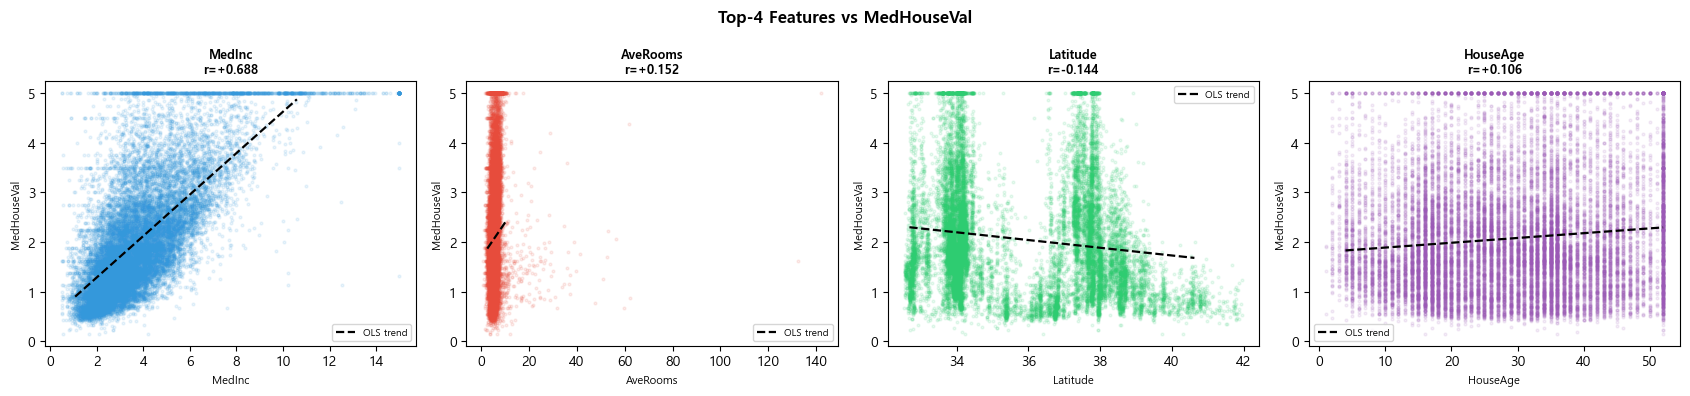

In [6]:

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
fig.suptitle('Top-4 Features vs MedHouseVal', fontsize=12, fontweight='bold')
sc_colors = ['#3498DB', '#E74C3C', '#2ECC71', '#9B59B6']

for ax, feat, col in zip(axes, top4_features, sc_colors):
    ax.scatter(df[feat], df['MedHouseVal'], alpha=0.1, s=4, color=col)
    z = np.polyfit(df[feat], df['MedHouseVal'], 1)
    xr = np.linspace(df[feat].quantile(0.01), df[feat].quantile(0.99), 200)
    ax.plot(xr, np.poly1d(z)(xr), 'k--', linewidth=1.6, label='OLS trend')
    ax.set_title(f'{feat}\nr={corr_with_target[feat]:+.3f}', fontsize=9, fontweight='bold')
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel('MedHouseVal', fontsize=8)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

<선택된 4개 변수와 MedHouseVal 산점도 분석 >

> 
1) MedInc & MedHouseVal : 4가지 변수 중 집값과 가장 강력한 선형관계를 보인다. 산점도의 점들이 우상향하는 뚜렷한 추세를 형성하며 지역주민의 소득수준이 높을수록 해당 지역의 주택가격도 상승한다는 것을 잘 보여주고 있고 모델 예측에서 가장 핵심적인 설명변수일 것 같다.
2) AveRooms & MedHouseVal : 상관계수가 0.152로 양의 상관관계이긴 하지만 매우 미미하고 대다수의 데이터가 좁은 범위에 밀집되어있어서 선형관계가 잘 보이지는 않는다.
3) Latitude & MedHouseVal : 상관계수는 -0.144로 약한 음의 관계이지만 산점도에서는 특정 위도구간에 넓은 범위의 집값이 모두 형성되어있다. 이는 특정 위도 구간에서 집값이 급등한다는 것을 알 수 있다.
4) HouseAge & MedHouseVal : 상관계수가 0.106으로 선형관계가 가장 낮고 산점도를 보면 전범위에 매우 넓게 점들이 퍼져 있어서 주택나이만으로는 가격을 설명하기 어렵다는 것을 알 수 있다.

##  모델 구현 

### Linear Regression

In [7]:
#  Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 모델 학습
lr = LinearRegression()
lr.fit(x_train_4, y_train_4)  # 훈련시키기 

# R² 출력
train_r2_lr = r2_score(y_train_4, lr.predict(x_train_4))  # 실제 train 데이터의 y값 & train 데이터의 설명변수들을 통해 예측한 y값 
test_r2_lr  = r2_score(y_test_4,  lr.predict(x_test_4))   # 실제 test 데이터의 y값 & test 데이터의 설명변수들을 통해 예측한 y값
print(f'Linear  ->  Train R² : {train_r2_lr:.4f} | Test R² : {test_r2_lr:.4f}')


Linear  ->  Train R² : 0.5225 | Test R² : 0.5043


Linear  ->  Train RMSE: 0.7989 | Test RMSE: 0.8059
Linear  ->  Train MAE:  0.5948  | Test MAE:  0.5994
  Train-Test R² 격차: 0.0182


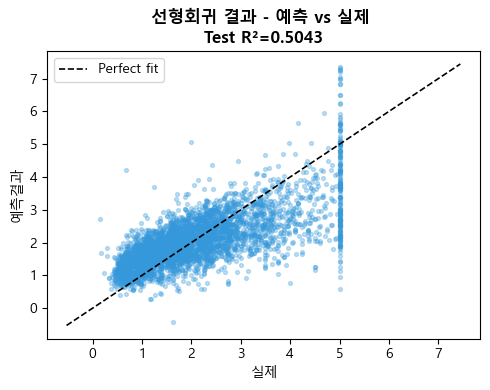

In [8]:

# RMSE(평균 제곱 오차), MAE(평균 절대 오차) 추가 출력
print(f'Linear  ->  Train RMSE: {np.sqrt(mean_squared_error(y_train_4, lr.predict(x_train_4))):.4f}'
      f' | Test RMSE: {np.sqrt(mean_squared_error(y_test_4, lr.predict(x_test_4))):.4f}')
print(f'Linear  ->  Train MAE:  {mean_absolute_error(y_train_4, lr.predict(x_train_4)):.4f}'
      f'  | Test MAE:  {mean_absolute_error(y_test_4, lr.predict(x_test_4)):.4f}')
print(f'  Train-Test R² 격차: {train_r2_lr - test_r2_lr:.4f}')

# Actual vs Predicted 시각화
preds_lr = lr.predict(x_test_4)
plt.figure(figsize=(5, 4))
plt.scatter(y_test_4, preds_lr, alpha=0.3, s=8, color='#3498DB')
lo = min(float(y_test_4.min()), float(preds_lr.min())) - 0.1
hi = max(float(y_test_4.max()), float(preds_lr.max())) + 0.1
plt.plot([lo, hi], [lo, hi], 'k--', linewidth=1.2, label='Perfect fit')
plt.title(f'선형회귀 결과 - 예측 vs 실제 \nTest R²={test_r2_lr:.4f}', fontweight='bold')
plt.xlabel('실제')
plt.ylabel('예측결과')
plt.legend()
plt.tight_layout()
plt.show()

### Polynomial Regression (degree=2)

In [9]:
# Polynomial Regression (degree=2)
from sklearn.preprocessing import PolynomialFeatures

# degree=2 다항 변환
poly = PolynomialFeatures(degree=2, include_bias=False)  # 2차항 
x_train_poly = poly.fit_transform(x_train_4)
x_test_poly  = poly.transform(x_test_4)
print(f'feature 수: 4 -> {x_train_poly.shape[1]}개 ')

# 모델 학습
lr_poly = LinearRegression()
lr_poly.fit(x_train_poly, y_train_4)

# R² 출력
train_r2_poly = r2_score(y_train_4, lr_poly.predict(x_train_poly))
test_r2_poly  = r2_score(y_test_4,  lr_poly.predict(x_test_poly))
print(f'Polynomial  ->  Train R² : {train_r2_poly:.4f}  |  Test R² : {test_r2_poly:.4f}')


feature 수: 4 -> 14개 
Polynomial  ->  Train R² : 0.5500  |  Test R² : 0.5188


Polynomial  ->  Train RMSE: 0.7756  |  Test RMSE: 0.7941
Polynomial  ->  Train MAE:  0.5773  |  Test MAE:  0.5832
  Train-Test R² 격차: 0.0312


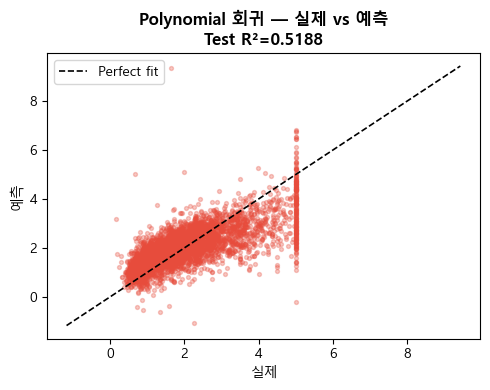

In [10]:

# RMSE, MAE 추가 출력
print(f'Polynomial  ->  Train RMSE: {np.sqrt(mean_squared_error(y_train_4, lr_poly.predict(x_train_poly))):.4f}'
      f'  |  Test RMSE: {np.sqrt(mean_squared_error(y_test_4, lr_poly.predict(x_test_poly))):.4f}')
print(f'Polynomial  ->  Train MAE:  {mean_absolute_error(y_train_4, lr_poly.predict(x_train_poly)):.4f}'
      f'  |  Test MAE:  {mean_absolute_error(y_test_4, lr_poly.predict(x_test_poly)):.4f}')
print(f'  Train-Test R² 격차: {train_r2_poly - test_r2_poly:.4f}')

# Actual vs Predicted 시각화
preds_poly = lr_poly.predict(x_test_poly)
plt.figure(figsize=(5, 4))
plt.scatter(y_test_4, preds_poly, alpha=0.3, s=8, color='#E74C3C')
lo = min(float(y_test_4.min()), float(preds_poly.min())) - 0.1
hi = max(float(y_test_4.max()), float(preds_poly.max())) + 0.1
plt.plot([lo, hi], [lo, hi], 'k--', linewidth=1.2, label='Perfect fit')
plt.title(f'Polynomial 회귀 — 실제 vs 예측\nTest R²={test_r2_poly:.4f}', fontweight='bold')
plt.xlabel('실제')
plt.ylabel('예측')
plt.legend()
plt.tight_layout()
plt.show()

### Ridge Regression 

In [11]:
#  Ridge Regression (degree=2, alpha=10)
from sklearn.linear_model import Ridge

# 모델 학습 (degree=2 다항 feature + Ridge(alpha=10))
ridge = Ridge(alpha=10)
ridge.fit(x_train_poly, y_train_4)

# R² 출력
train_r2_ridge = r2_score(y_train_4, ridge.predict(x_train_poly))
test_r2_ridge  = r2_score(y_test_4,  ridge.predict(x_test_poly))
print(f'Ridge  ->  Train R² : {train_r2_ridge:.4f}  |  Test R² : {test_r2_ridge:.4f}')



Ridge  ->  Train R² : 0.5500  |  Test R² : 0.5188


Ridge      -> Train RMSE: 0.7756 | Test RMSE: 0.7941
Ridge      -> Train MAE:  0.5773  | Test MAE:  0.5832
  Train-Test R² 격차: 0.0312


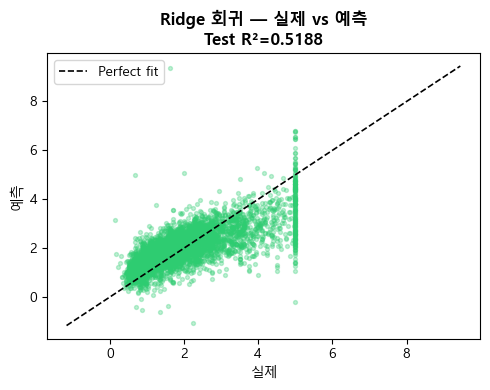


3개 모델 비교

전체 모델 성능 비교표:


,Model,Train R²,Test R²,Gap,Test RMSE
0,Linear,0.52254,0.50432,0.01822,0.80595
1,Polynomial,0.55005,0.51881,0.03124,0.79408
2,Ridge(a=10),0.55005,0.51881,0.03124,0.79407


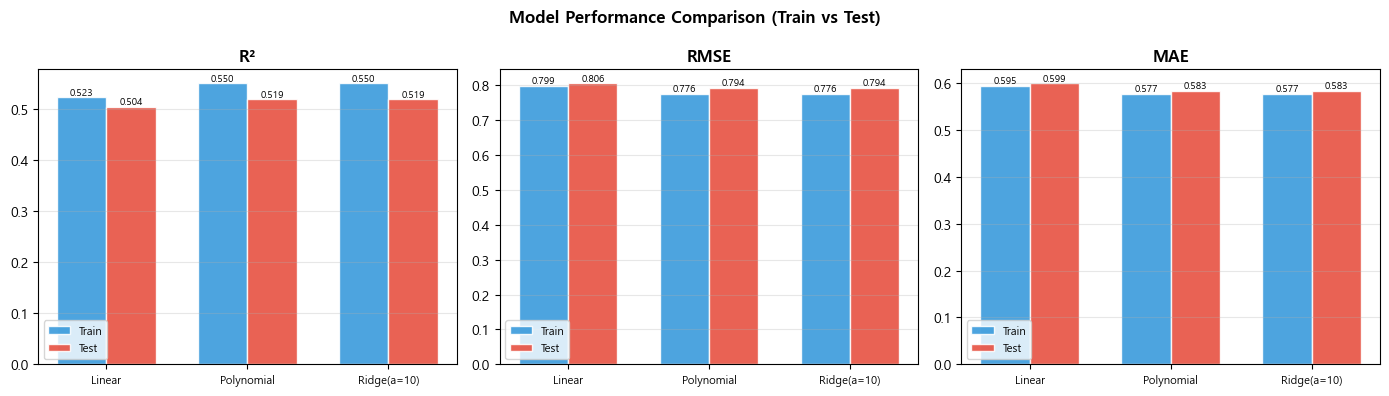

In [12]:

# RMSE, MAE 추가 출력
print(f'Ridge      -> Train RMSE: {np.sqrt(mean_squared_error(y_train_4, ridge.predict(x_train_poly))):.4f}'
      f' | Test RMSE: {np.sqrt(mean_squared_error(y_test_4, ridge.predict(x_test_poly))):.4f}')
print(f'Ridge      -> Train MAE:  {mean_absolute_error(y_train_4, ridge.predict(x_train_poly)):.4f}'
      f'  | Test MAE:  {mean_absolute_error(y_test_4, ridge.predict(x_test_poly)):.4f}')
print(f'  Train-Test R² 격차: {train_r2_ridge - test_r2_ridge:.4f}')

# Actual vs Predicted 시각화
preds_ridge = ridge.predict(x_test_poly)
plt.figure(figsize=(5, 4))
plt.scatter(y_test_4, preds_ridge, alpha=0.3, s=8, color='#2ECC71')
lo = min(float(y_test_4.min()), float(preds_ridge.min())) - 0.1
hi = max(float(y_test_4.max()), float(preds_ridge.max())) + 0.1
plt.plot([lo, hi], [lo, hi], 'k--', linewidth=1.2, label='Perfect fit')
plt.title(f'Ridge 회귀 — 실제 vs 예측\nTest R²={test_r2_ridge:.4f}', fontweight='bold')
plt.xlabel('실제')
plt.ylabel('예측')
plt.legend()
plt.tight_layout()
plt.show()

### 3개 모델 비교 
print('\n3개 모델 비교')

# 세 모델 전체 비교표
print('\n전체 모델 성능 비교표:')
summary = pd.DataFrame({
    'Model':     ['Linear', 'Polynomial', 'Ridge(a=10)'],
    'Train R²':  [train_r2_lr,   train_r2_poly,   train_r2_ridge],
    'Test R²':   [test_r2_lr,    test_r2_poly,    test_r2_ridge],
    'Gap':       [train_r2_lr - test_r2_lr,
                  train_r2_poly - test_r2_poly,
                  train_r2_ridge - test_r2_ridge],
    'Test RMSE': [np.sqrt(mean_squared_error(y_test_4, lr.predict(x_test_4))),
                  np.sqrt(mean_squared_error(y_test_4, lr_poly.predict(x_test_poly))),
                  np.sqrt(mean_squared_error(y_test_4, ridge.predict(x_test_poly)))],
})
display(summary.round(5))

# 성능 비교 bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Model Performance Comparison (Train vs Test)', fontsize=12, fontweight='bold')
models = ['Linear', 'Polynomial', 'Ridge(a=10)']
x = np.arange(3)
w = 0.35
metrics_data = [
    ('R²',
     [train_r2_lr, train_r2_poly, train_r2_ridge],
     [test_r2_lr,  test_r2_poly,  test_r2_ridge]),
    ('RMSE',
     [np.sqrt(mean_squared_error(y_train_4, lr.predict(x_train_4))),
      np.sqrt(mean_squared_error(y_train_4, lr_poly.predict(x_train_poly))),
      np.sqrt(mean_squared_error(y_train_4, ridge.predict(x_train_poly)))],
     [np.sqrt(mean_squared_error(y_test_4, lr.predict(x_test_4))),
      np.sqrt(mean_squared_error(y_test_4, lr_poly.predict(x_test_poly))),
      np.sqrt(mean_squared_error(y_test_4, ridge.predict(x_test_poly)))]),
    ('MAE',
     [mean_absolute_error(y_train_4, lr.predict(x_train_4)),
      mean_absolute_error(y_train_4, lr_poly.predict(x_train_poly)),
      mean_absolute_error(y_train_4, ridge.predict(x_train_poly))],
     [mean_absolute_error(y_test_4, lr.predict(x_test_4)),
      mean_absolute_error(y_test_4, lr_poly.predict(x_test_poly)),
      mean_absolute_error(y_test_4, ridge.predict(x_test_poly))])
]
for ax, (label, tv, tev) in zip(axes, metrics_data):
    b1 = ax.bar(x - w/2, tv,  w, label='Train', color='#3498DB', alpha=0.88, edgecolor='white')
    b2 = ax.bar(x + w/2, tev, w, label='Test',  color='#E74C3C', alpha=0.88, edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=8)
    ax.legend(fontsize=8) 
    ax.grid(axis='y', alpha=0.3)
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=7)
plt.tight_layout()
plt.show()



 < 3가지 모델의 예측 vs 실제 산점도 해석 >
> 3가지 모델 모두 y=x에서 크게 벗어나지는 않는다. 하지만 약간 벗어나는 패턴이 모두 비슷한데, MedHouseVal이 실제로 4~5인 구간에서 예측값이 실제보다 약간 저렴하게 예측되는 경향이 있다. 이는 앞에 히스토그램에서 확인한 집값이 5를 넘어가는 것들을 모두 5라고 정해놓은 것 때문인 것 같다. 이것 때문에 고가 주택일수록 예측오차가 커진 것으로 보인다. 

 < 3가지 모델 성능 막대 그래프 해석 >
> R^2 막대 그래프를 보면 Linear, Ploynomial, Ridge 순으로 성능이 증가한다. train데이터와 test데이터 간 성능 차이가 과적합이 얼마나 되었는가를 의미하는데 3가지 모두 격차가 매우 작으므로 과적합은 아닌 것으로 보인다. RMSE와 MAE는 낮을수록 좋은데 3가지 모델 모두 비슷하지만 성능지표를 모두 종합적으로 봤을 때 3가지 모델 모두 성능이 좋은 것은 아니다. 따라서 이 4가지 변수만으로는 집값을 충분히 설명하지 못하는 것을 알 수 있다.

## 해석 및 분석


(1) 과적합 판단

>  과적합은 train 데이터에 대해서는 성능이 매우 좋지만 test 데이터 등 새로운 데이터에 대해서는 train 데이터 성능에 비해 매우 떨어지는 것을 말한다. 
>1) Linear 모델 : train R^2 점수 = 0.5225 , test R^2 점수 = 0.5043 으로 둘의 차이가 0.05 이하로 매우 작다. 즉 train데이터 예측성능과 test데이터 예측 성능이 비슷하기 때문에 과적합이 발생하지 않았다고 할 수 있다. 
>2) Ploynomial 모델 : train R^2 점수 = 0.5501 , test R^2 점수 = 0.5188 로 둘의 차이가 0.05 이하로 매우 작다. 따라서 이 모델도 train 데이터 예측성능과 test 데이터
예측성능이 비슷하기 때문에 과적합이 발생했다고 보기 어렵다. 
>3) Ridge 모델 : train R^2 점수 = 0.5501 , test R^2 점수 = 0.5188 로 둘의 차이가 0.05 이하로 매우 작다. 따라서 train 데이터 예측성능과 test 데이터 예측성능이 비슷하기 때문에 과적합이 발생하지 않은 것으로 보인다. 

(2) Ridge 원리

> 모델이 train 데이터를 완벽하게 따라가기 위해서는 w값이 매우 크거나 작게된다. 이렇게 하면 결국 train 데이터는 성능이 매우 좋게 예측할 수 있지만 train데이터에만 최적화 되어있기 때문에 다른 test 데이터 등에 대해서는 성능이 매우 떨어지게 된다. 따라서 w값을 매우 크거나 작게 정해서 train 데이터에만 딱 맞추지 않도록 하는 제약이 필요하다. 그 역할을 패널티항이 하는데 Ridge에서는 패널티항으로 람다x(w^2 합)을 사용한다. 이 패널티항을 목적함수에 추가하여 목적함수를 MSE + 람다(w^2 합) 으로 한다면 예측오차를 줄이는것 & (w^2)을 작게 하는 것을 동시에 고려하여 목적함수를 최소화 한다. 특히 람다를 크게 설정할수록 (w^2)를 작게하는 것에 중점을 두게 된다. 예측오차를 줄이는 것과 (w^2)를 작게 하는 것을 동시에 고려한다면 모델이 오차를 어는 정도 감수하면서 w를 적당히 작게 유지하기 때문에 모델이 train 데이터에만 딱 맞게 되는 것이 아니라 다른 데이터에 대해서도 일반화된다. 즉 과적합이 완화되는 것이다.  

alpha별 Ridge 성능 표:


,alpha,Train_R2,Test_R2,Test_RMSE,Gap,CoefL2Norm
0,0.001,0.5500,0.5188,0.7941,0.0312,1.0658
1,0.010,0.5500,0.5188,0.7941,0.0312,1.0658
2,0.100,0.5500,0.5188,0.7941,0.0312,1.0658
3,1.000,0.5500,0.5188,0.7941,0.0312,1.0656
4,10.000,0.5500,0.5188,0.7941,0.0312,1.0635
5,100.000,0.5499,0.5187,0.7941,0.0312,1.0430
6,1000.000,0.5434,0.5129,0.7989,0.0305,0.8933
7,100000.000,0.2130,0.2036,1.0215,0.0093,0.1291



최적 alpha: 10.0  (Test R²=0.5188)


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

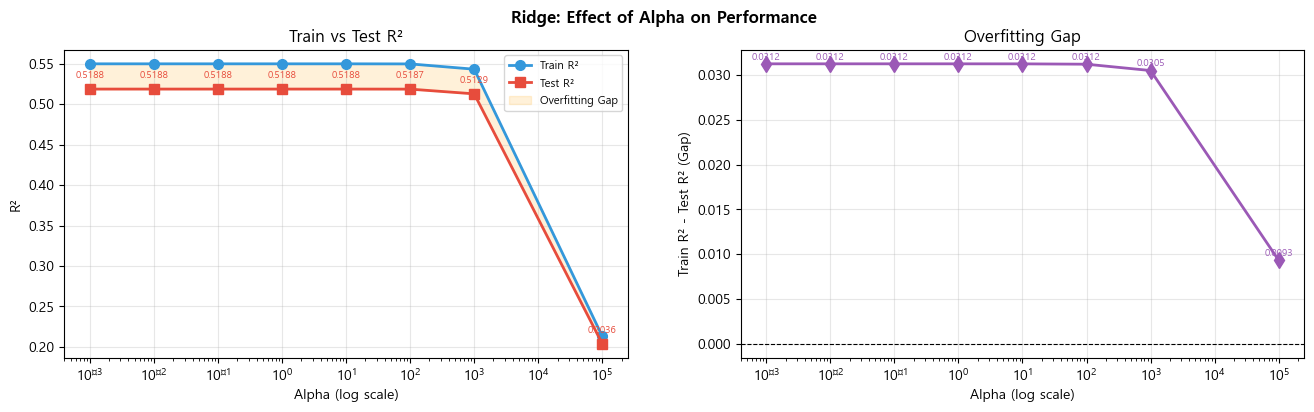

In [13]:
# alpha 값 변화에 따른 Ridge 모델의 성능 변화 실험 

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 100000]
alpha_results = []

for a in alphas:
    r_model = Ridge(alpha=a)
    r_model.fit(x_train_poly, y_train_4)
    tr2       = r2_score(y_train_4, r_model.predict(x_train_poly))
    ter2      = r2_score(y_test_4,  r_model.predict(x_test_poly))
    trmse     = np.sqrt(mean_squared_error(y_test_4, r_model.predict(x_test_poly)))
    gap       = tr2 - ter2
    coef_norm = np.linalg.norm(r_model.coef_) 
    alpha_results.append({'alpha': a, 'Train_R2': tr2, 'Test_R2': ter2,
                          'Test_RMSE': trmse, 'Gap': gap, 'CoefL2Norm': coef_norm})

alpha_df = pd.DataFrame(alpha_results)

# 결과 DataFrame 표로 출력
print('alpha별 Ridge 성능 표:')
display(alpha_df.round(4))

best_row = alpha_df.loc[alpha_df['Test_R2'].idxmax()]
print(f'\n최적 alpha: {best_row["alpha"]}  (Test R²={best_row["Test_R2"]:.4f})')

# alpha vs R² 그래프
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Ridge: Effect of Alpha on Performance', fontsize=12, fontweight='bold')

# 그래프 1: Train vs Test R²
ax1 = axes[0]
ax1.plot(alpha_df['alpha'], alpha_df['Train_R2'], 'o-', color='#3498DB', lw=2, ms=7, label='Train R²')
ax1.plot(alpha_df['alpha'], alpha_df['Test_R2'],  's-', color='#E74C3C', lw=2, ms=7, label='Test R²')
ax1.fill_between(alpha_df['alpha'], alpha_df['Train_R2'], alpha_df['Test_R2'],
                 alpha=0.15, color='orange', label='Overfitting Gap')
ax1.set_xscale('log')
ax1.set_xlabel('Alpha (log scale)') ; ax1.set_ylabel('R²') ; ax1.set_title('Train vs Test R²')
ax1.legend(fontsize=8) ; ax1.grid(alpha=0.3) 
for _, row in alpha_df.iterrows():
    ax1.annotate(f"{row['Test_R2']:.4f}", (row['alpha'], row['Test_R2']),
                 textcoords='offset points', xytext=(0, 8), ha='center', fontsize=7, color='#E74C3C')

# 그래프 2: 과적합 Gap
ax2 = axes[1]
ax2.plot(alpha_df['alpha'], alpha_df['Gap'], 'd-', color='#9B59B6', lw=2, ms=8)
ax2.axhline(0, color='black', lw=0.8, linestyle='--')
ax2.set_xscale('log')
ax2.set_xlabel('Alpha (log scale)')
ax2.set_ylabel('Train R² - Test R² (Gap)')
ax2.set_title('Overfitting Gap')
ax2.grid(alpha=0.3)
for _, row in alpha_df.iterrows():
    ax2.text(row['alpha'], row['Gap'] + 0.0005, f"{row['Gap']:.4f}",
             ha='center', fontsize=7, color='#9B59B6')



 (3) alpha 값 변화에 따른 모델 성능 결과 분석

> 실험 결과를 보면, 알파가 작은 구간에서는 train R^2과 test R^2, 그리고 이 둘의 차이가 거의 일정하게 유지되다가 알파가 1000이 되었을 때 train 데이터와 test데이터 성능 차이가 조금 더 작아지는 것을 알 수 있다. 하지만 성능 차이가 조금 작아짐과 동시에 각 성능 점수도 조금 작아진다. 따라서 이는 모델이 너무 일반화과 되어 모델의 성능 자체가 떨어진 것으로 보인다. 알파가 1000 이상부터는 train R^2, test R^2, 성능 차이 이 3가지 값 모두 매우 급격히 감소한다. 이것은 알파값이 너무 커져서 (w^2)을 감소시키는 것에 매우 중점을 둔 결과로 모델이 너무 단순하여 과소적합 되었음을 알 수 있다. 반대로, 알파가 매우 작으면 사실상 linear 모델과 다를게 없어서 과적합을 완화하기 어려운데 현재 0.001 ~ 100 까지 별로 눈에 띄는 차이가 없다. 이는 변수의 개수가 적어서 그렇게 나타나는 것으로 보이고 변수가 만약 많은 상황이라면 과적합이 나타날 가능성이 크다.


feature 수: 8 -> 44개 (2차 항 + 교호작용항 포함)
Ridge  ->  Train R² : 0.6850  |  Test R² : 0.6559
alpha별 Ridge 성능 표:


,alpha,Train_R2,Test_R2,Test_RMSE,Gap,CoefL2Norm
0,0.001,0.6853,0.6457,0.6814,0.0396,3.3009
1,0.010,0.6853,0.6457,0.6814,0.0396,3.3007
2,0.100,0.6853,0.6458,0.6813,0.0395,3.2986
3,1.000,0.6853,0.6469,0.6802,0.0384,3.2779
4,10.000,0.6850,0.6559,0.6715,0.0291,3.0999
5,100.000,0.6764,0.6586,0.6689,0.0179,2.2993
6,1000.000,0.6177,0.5655,0.7545,0.0522,1.1643



최적 alpha: 100.0  (Test R²=0.6586)


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

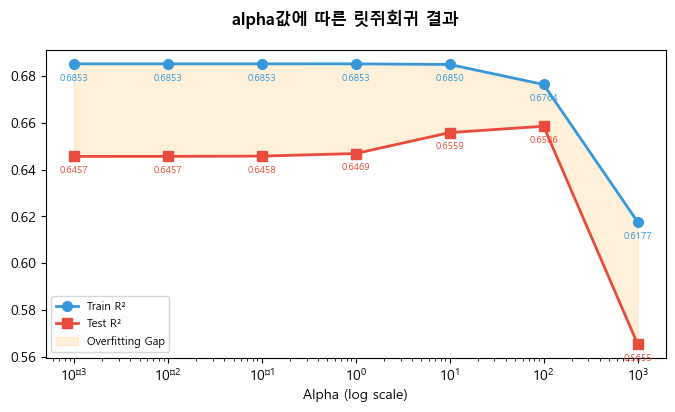

In [14]:


'''릿쥐는 라쏘와 다르게 패널티항에서 (w^2)을 사용한다. 따라서 미분했을 때 w가 남아있어서 w가 0에 가까워질수록 미분값도 0에 가까워진다. 
즉, w를 더 줄일려는 힘이 약해지므로 w를 완전히 0으로 만들지 못해서 해당 변수의 영향력이 남아있다. 
릿쥐 회귀를 사용할 때 만약 데이터의 모든 변수들이 유효하다면, 과적합은 완화하면서 모든 변수들의 영향력을 살려두는 릿쥐회귀 특성 상 
4개 변수만 선택하는 것보다 변수를 모두 사용했을 때 성능이 더 좋아질 것으로 예상하였다. 
그래서 전체 변수를 사용하여 릿쥐 회귀로 예측해봤고 이때 알파값 변화에 따라 모델 성능을 비교해 보았다.  '''

# degree=2 다항 변환
poly = PolynomialFeatures(degree=2, include_bias=False)  # 2차항 
x_train_poly2 = poly.fit_transform(x_train_scaled)
x_test_poly2  = poly.transform(x_test_scaled)
print(f'\nfeature 수: 8 -> {x_train_poly2.shape[1]}개 (2차 항 + 교호작용항 포함)')

#ridge = Ridge(alpha=10)
ridge.fit(x_train_poly2, y_train)

# R² 출력
train_r2_ridge = r2_score(y_train, ridge.predict(x_train_poly2))
test_r2_ridge  = r2_score(y_test,  ridge.predict(x_test_poly2))
print(f'Ridge  ->  Train R² : {train_r2_ridge:.4f}  |  Test R² : {test_r2_ridge:.4f}')
# alpha 값 변화에 따른 Ridge 모델의 성능 변화 실험 코드

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
alpha_results = []

for a in alphas:
    r_model = Ridge(alpha=a)
    r_model.fit(x_train_poly2, y_train)
    tr2       = r2_score(y_train, r_model.predict(x_train_poly2))
    ter2      = r2_score(y_test,  r_model.predict(x_test_poly2))
    trmse     = np.sqrt(mean_squared_error(y_test, r_model.predict(x_test_poly2)))
    gap       = tr2 - ter2
    coef_norm = np.linalg.norm(r_model.coef_)  # [+α] 계수 수축 정도 확인
    alpha_results.append({'alpha': a, 'Train_R2': tr2, 'Test_R2': ter2,
                          'Test_RMSE': trmse, 'Gap': gap, 'CoefL2Norm': coef_norm})

alpha_df = pd.DataFrame(alpha_results)

# 결과 DataFrame 표로 출력
print('alpha별 Ridge 성능 표:')
display(alpha_df.round(4))

best_row = alpha_df.loc[alpha_df['Test_R2'].idxmax()]
print(f'\n최적 alpha: {best_row["alpha"]}  (Test R²={best_row["Test_R2"]:.4f})')

# 그래프 
fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle('alpha값에 따른 릿쥐회귀 결과', fontsize=12, fontweight='bold')

# Train vs Test R²
ax.plot(alpha_df['alpha'], alpha_df['Train_R2'], 'o-', color='#3498DB', lw=2, ms=7, label='Train R²')
ax.plot(alpha_df['alpha'], alpha_df['Test_R2'],  's-', color='#E74C3C', lw=2, ms=7, label='Test R²')
ax.fill_between(alpha_df['alpha'], alpha_df['Train_R2'], alpha_df['Test_R2'],
                 alpha=0.15, color='orange', label='Overfitting Gap')
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)') ; ax1.set_ylabel('R²') ; ax1.set_title('Train vs Test R²')
ax.legend(fontsize=8) ; ax1.grid(alpha=0.3) 
for _, row in alpha_df.iterrows():
    ax.annotate(f"{row['Test_R2']:.4f}", (row['alpha'], row['Test_R2']),
                 textcoords='offset points', xytext=(0, -12), ha='center', fontsize=7, color='#E74C3C')
    ax.annotate(f"{row['Train_R2']:.4f}", (row['alpha'], row['Train_R2']),
                 textcoords='offset points', xytext=(0, -12), ha='center', fontsize=7, color='#3498DB')




 < 모든 변수를 사용 & 알파값 변경한 결과 분석 >
> 변수를 4개 선택했을 때 릿쥐 회귀 결과 (알파가 10일 때) train R^2 = 0.55 , test R^2 = 0.52 였는데 
모든 변수를 사용한 결과 train R^2 = 0.69 , test R^2 = 0.66 으로 train, test 둘 다 성능이 약 14% 증가하였다.
릿쥐 회귀는 모든 변수의 영향력을 살려둔다는 점을 고려하면 이 데이터의 모든 변수는 MedHouseVal 변수 값을 예측하는데 유효함을 알 수 있다.  
또한 알파가 100일 때 train에 대한 성능은 약간 감소하지만 test에 대한 성능은 최고점이며, train과 test 데이터에 대한 성능 차이가 가장 최소화되므로
최적의 알파값이 100임을 알 수 있다.
마지막으로 알파가 1000일 때부터는 train, test 데이터에 대한 성능이 모두 급격히 감소하므로 이때부터는 모델이 (w^2)를 감소시키는데 너무 중점을 두어
지나치게 일반화되어서 과소적합 되었음을 확인할 수 있다.

### 라쏘 회귀

In [15]:

# Lasso Regression
# Ridge(L2)와 달리 L1 페널티를 사용  (변수 선택 효과)
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

lasso = Lasso(alpha=0.01)
lasso.fit(x_train_4, y_train_4)

train_r2_lasso = r2_score(y_train_4, lasso.predict(x_train_4))
test_r2_lasso  = r2_score(y_test_4,  lasso.predict(x_test_4))
print(f'Lasso     -> Train R²: {train_r2_lasso:.4f} | Test R²: {test_r2_lasso:.4f}')
print(f'Lasso     -> Train RMSE: {np.sqrt(mean_squared_error(y_train_4, lasso.predict(x_train_4))):.4f}'
      f' | Test RMSE: {np.sqrt(mean_squared_error(y_test_4, lasso.predict(x_test_4))):.4f}')
print(f'Lasso      -> Train MAE:  {mean_absolute_error(y_train_4, lasso.predict(x_train_4)):.4f}'
      f'  | Test MAE:  {mean_absolute_error(y_test_4,  lasso.predict(x_test_4)):.4f}')
print(f'  Train-Test R² 격차: {train_r2_lasso - test_r2_lasso:.4f}')

# 계수 확인 (0이 된 계수 확인)
print(f'\nLasso 계수 (0이 되면 해당 변수 제거 효과):')
for fname, coef in zip(x_train_4.columns, lasso.coef_):
    print(f'  {fname:12s}: {coef:.4f}{"  ← 0으로 수축됨" if abs(coef) < 0.001 else ""}')




Lasso     -> Train R²: 0.5222 | Test R²: 0.5043
Lasso     -> Train RMSE: 0.7992 | Test RMSE: 0.8060
Lasso      -> Train MAE:  0.5958  | Test MAE:  0.6001
  Train-Test R² 격차: 0.0179

Lasso 계수 (0이 되면 해당 변수 제거 효과):
  MedInc      : 0.8198
  AveRooms    : -0.0396
  Latitude    : -0.0892
  HouseAge    : 0.2038


 < lasso regression 모델 분석 >
> 라쏘 회귀 모델의 성능 지표를 분석한 결과, 훈련 데이터와 테스트 데이터의 R^2 점수가 약 0.50~0.52 수준으로 나타났다. 훈련과 테스트 간의 격차가 0.0179로 매우 작고, 오차 지표인 RMSE(0.8060)와 MAE(0.6001) 역시 안정적인 수치를 보여 모델의 일반화 성능은 우수하지만, 전반적인 예측력 자체는 그리 높지 않은 과소적합을 보인다. 이는 라쏘 모델의 특성상 불필요한 변수의 계수를 0으로 만드는 과정에서 예측에 필요한 정보가 일부 손실되었을 가능성으로 인한 것으로 보인다.

### California Housing 데이터의 MedHouseVal을 기준으로 고가(상위 50%) / 저가(하위 50%) 로 이진 분류 문제로 변환

  Train — 고가(1): 8273  저가(0): 8239
  Test  — 고가(1): 2052   저가(0): 2076

분류 모델 test 성능 비교표 (MedHouseVal 이진 분류):


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.8932,0.8962,0.8879,0.8920
1,KNN,0.8307,0.8279,0.8324,0.8301
2,Logistic Regression,0.8249,0.8237,0.8241,0.8239
3,SVM,0.8164,0.8165,0.8134,0.8149
4,Decision Tree,0.7873,0.8706,0.6720,0.7585


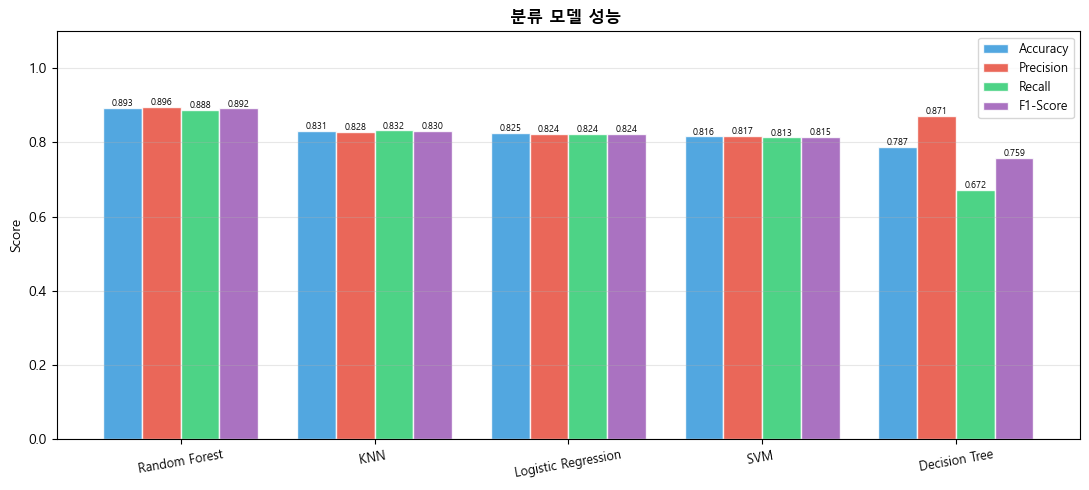

In [19]:

# 분류 모델로 변환 후 평가
# MedHouseVal을 중앙값 기준 이진 분류로 변환
# (고가=1: 상위 50%, 저가=0: 하위 50%)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, classification_report)
import pandas as pd
import numpy as np

# 타겟 이진 변환 (중앙값 기준)
median_val = y.median()
y_bin      = (y >= median_val).astype(int)  # 1=고가, 0=저가

y_bin_train = y_bin.loc[x_train.index].reset_index(drop=True)
y_bin_test  = y_bin.loc[x_test.index].reset_index(drop=True)

print(f'  Train — 고가(1): {y_bin_train.sum()}  저가(0): {(y_bin_train==0).sum()}')
print(f'  Test  — 고가(1): {y_bin_test.sum()}   저가(0): {(y_bin_test==0).sum()}')


models = {
    'KNN ':          KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM ':     LinearSVC(C=1, max_iter=10000),
}

# 각 모델 학습 및 평가
results = []
for name, model in models.items():
    model.fit(x_train_scaled, y_bin_train)
    pred = model.predict(x_test_scaled)
    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_bin_test,  pred),
        'Precision': precision_score(y_bin_test, pred, zero_division=0),
        'Recall':    recall_score(y_bin_test,    pred, zero_division=0),
        'F1-Score':  f1_score(y_bin_test,        pred, zero_division=0),
    })

# 결과 표 
result_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
result_df = result_df.reset_index(drop=True)
print('\n분류 모델 test 성능 비교표 (MedHouseVal 이진 분류):')
display(result_df.round(4))

# 시각화 
fig, ax = plt.subplots(figsize=(11, 5))
x      = np.arange(len(result_df))
width  = 0.2
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
bar_colors  = ['#3498DB', '#E74C3C', '#2ECC71', '#9B59B6']

for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
    bars = ax.bar(x + i*width, result_df[metric], width,
                  label=metric, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=6.5)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(result_df['Model'], fontsize=9, rotation=10)
ax.set_ylabel('Score', fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title('분류 모델 성능 ', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()